Loading NuScenes tables for version v1.0-mini...
Loading nuScenes-panoptic...
32 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
404 panoptic,
Done loading in 0.445 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.

Rendering camera image without annotations...


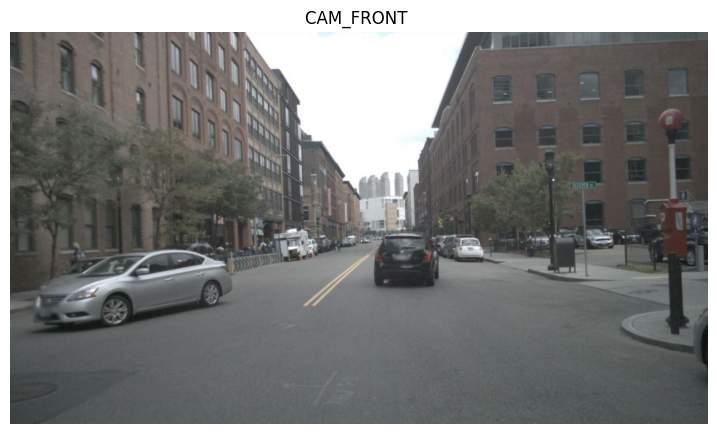


Rendering camera image with annotations...


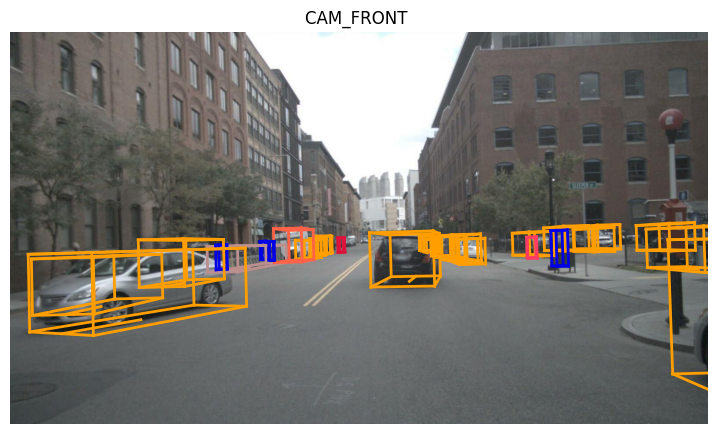


Rendering LiDAR point cloud...


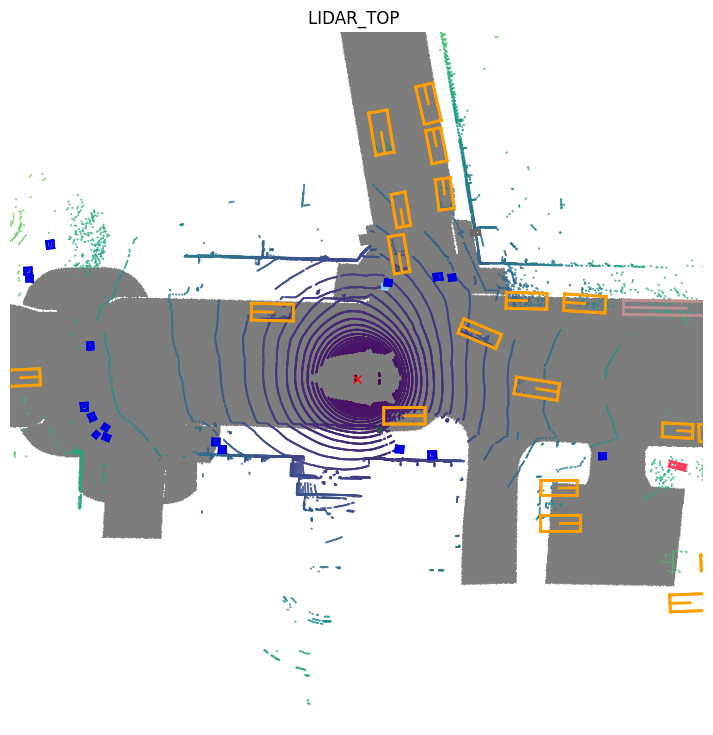


Scene: 2
Sample: 22
Token: d0ecf474e0e64950aa265cd44b9c9d75
Number of annotations: 62

--- Object Category Distribution ---
human.pedestrian.adult: 25 instance(s)
vehicle.car: 30 instance(s)
movable_object.pushable_pullable: 1 instance(s)
human.pedestrian.child: 1 instance(s)
movable_object.trafficcone: 1 instance(s)
static_object.bicycle_rack: 1 instance(s)
vehicle.motorcycle: 1 instance(s)
vehicle.bicycle: 1 instance(s)
vehicle.truck: 1 instance(s)

Data balanced check:
Balance condition met. Max count: 30, Min count: 1
Balance ratio: 30.00

--- Object Distances and Details from Car (Using Lidar and sorted by Distance) ---
Object: movable_object.trafficcone, Distance from car: 6.52 meters (category token: 85abebdccd4d46c7be428af5a6173947, category index: 12, annotation token: 847ba6b14206400e8a1f8666f79761d2, attribute: None)
Object: vehicle.car, Distance from car: 7.05 meters (category token: fd69059b62a3469fbaef25340c0eab7f, category index: 17, annotation token: 4c809c8ee9134fa39c

In [1]:
from nuscenes.nuscenes import NuScenes
from collections import Counter
import numpy as np
from pyquaternion import Quaternion  # for rotations
from nuscenes.utils.data_classes import LidarPointCloud  # Import this!

# ---- CONFIGURATION ----
scene_index = 1        # any scene index (e.g., 0 to 849)
sample_index = 21       # any sample index within the scene
camera_channel = 'CAM_FRONT'  # e.g., 'CAM_FRONT', 'CAM_BACK', 'CAM_FRONT_LEFT', etc.
lidar_channel = 'LIDAR_TOP'   # Common LiDAR channel name

# ---- LOAD NUSCENES DATASET ----
nusc = NuScenes(version='v1.0-mini', dataroot='/data/sets/nuscenes', verbose=True)

# ---- LOAD SCENE AND TRAVERSE TO SAMPLE ----
scene = nusc.scene[scene_index]
sample_token = scene['first_sample_token']

# Traverse to the target sample
for i in range(sample_index):
    sample = nusc.get('sample', sample_token)
    if not sample['next']:
        raise ValueError(f"Scene {scene_index} has fewer than {sample_index + 1} samples.")
    sample_token = sample['next']

#  GET SAMPLE AND DATA TOKEN FOR CAMERA AND LIDAR
target_sample = nusc.get('sample', sample_token)

if camera_channel not in target_sample['data']:
    raise ValueError(f"Camera channel '{camera_channel}' not found in sample.")
cam_token = target_sample['data'][camera_channel]

if lidar_channel not in target_sample['data']:
    raise ValueError(f"Lidar channel '{lidar_channel}' not found in sample.")
lidar_token = target_sample['data'][lidar_channel]

# RENDER IMAGE WITHOUT ANNOTATIONS 
print("\nRendering camera image without annotations...")
nusc.render_sample_data(cam_token, with_anns=False)

# RENDER IMAGE WITH ANNOTATIONS 
print("\nRendering camera image with annotations...")
nusc.render_sample_data(cam_token, with_anns=True)

# RENDER LIDAR POINT CLOUD 
print("\nRendering LiDAR point cloud...")
nusc.render_sample_data(lidar_token)

#  ANNOTATION PROCESSING 
annotation_tokens = target_sample['anns']
print(f"\nScene: {scene_index + 1}")
print(f"Sample: {sample_index + 1}")
print(f"Token: {sample_token}")
print(f"Number of annotations: {len(annotation_tokens)}")

# Count object categories
categories = [nusc.get('sample_annotation', ann_token)['category_name'] for ann_token in annotation_tokens]
category_counts = Counter(categories)

#  CATEGORY DISTRIBUTION 
print("\n--- Object Category Distribution ---")
for category, count in category_counts.items():
    print(f"{category}: {count} instance(s)")

#  BALANCE CHECK 
print("\nData balanced check:")
if category_counts:
    max_count = max(category_counts.values())
    min_count = min(category_counts.values())
    balance_ratio = max_count / max(min_count, 1)
    print(f"Balance condition met. Max count: {max_count}, Min count: {min_count}")
    print(f"Balance ratio: {balance_ratio:.2f}")
else:
    print("No annotations found in this sample.")

#  OBJECT DISTANCE AND DETAILS CALCULATION 
print("\n--- Object Distances and Details from Car (Using Lidar and sorted by Distance) ---")

#  LOAD LIDAR POINT CLOUD 
lidar_data = nusc.get('sample_data', lidar_token)
ego_pose = nusc.get('ego_pose', lidar_data['ego_pose_token'])
ego_translation = ego_pose['translation']

# Create a list to store object details with their distances
object_distances = []

# Create a mapping from category name to index
category_name_to_index = {cat['name']: i for i, cat in enumerate(nusc.category)}

#  LOOP THROUGH ANNOTATIONS and CALCULATE DISTANCE AND DETAILS 
for ann_token in target_sample['anns']:  # Iterate through annotation tokens in the sample
    annotation = nusc.get('sample_annotation', ann_token)  # Get the annotation using nusc.get()
    object_translation = annotation['translation']  # Object's location
    instance_token = annotation['instance_token']
    instance_data = nusc.get('instance', instance_token)
    category_token = instance_data['category_token']
    category_name = nusc.get('category', category_token)['name']

    object_class = category_name
    attribute_token = annotation['attribute_tokens'][0] if annotation['attribute_tokens'] else None  # Get the first attribute token
    attribute = nusc.get('attribute', attribute_token)['name'] if attribute_token else "None"

    # Calculate distance
    distance = np.linalg.norm(np.array(object_translation) - np.array(ego_translation))

    # Get category index
    category_index = category_name_to_index.get(category_name, -1)

    object_distances.append({
        'distance': distance,
        'object_class': object_class,
        'ann_token': ann_token,
        'attribute': attribute,
        'category_index': category_index,  # Add the category index
        'category_token': category_token, # Add the category token
    })

# Sort the list of objects based on their distance from the car
object_distances.sort(key=lambda item: item['distance'])

#  PRINT OBJECT DETAILS SORTED BY DISTANCE 

for obj_data in object_distances:
    print(f"Object: {obj_data['object_class']}, Distance from car: {obj_data['distance']:.2f} meters "
          f"(category token: {obj_data['category_token']}, category index: {obj_data['category_index']}, annotation token: {obj_data['ann_token']}, attribute: {obj_data['attribute']})")